<a href="https://colab.research.google.com/github/vshnu07/img_classifier/blob/main/img_classifer_lesser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install opencv-python scikit-learn matplotlib numpy

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

print(f"training data shape: {x_train.shape}")
print(f"training label shape: {y_train.shape}")
print(f"testing data shape: {x_test.shape}")
print(f"testing label shape: {x_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
training data shape: (60000, 28, 28)
training label shape: (60000,)
testing data shape: (10000, 28, 28)
testing label shape: (10000, 28, 28)


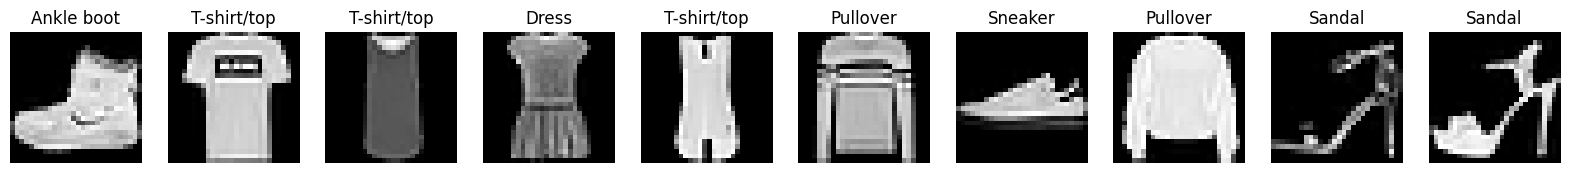

In [ ]:
import matplotlib.pyplot as plt

def plot_intial_img(images,lables,class_names):
  fig,axes=plt.subplots(1,10,figsize=(20,3))
  for i in range(10):
    ax=axes[i]
    ax.imshow(images[i],cmap='grey')
    ax.set_title(class_names[lables[i]])
    ax.axis('off')
  plt.show()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plot_intial_img(x_train,y_train,class_names)

In [ ]:
x_train=x_train/255.0
x_test=x_test/255.0

#reshape
x_train=x_train.reshape(x_train.shape[0],28,28,1)
x_test=x_test.reshape(x_test.shape[0],28,28,1)

print(f"Processed training data shape: {x_train.shape}")
print(f"Processed testing data shape: {x_test.shape}")

Processed training data shape: (60000, 28, 28, 1)
Processed testing data shape: (10000, 28, 28, 1)


In [ ]:
#use smaller data
x_train_small = x_train[:10000]
y_train_small = y_train[:10000]
x_test_small = x_test[:2000]
y_test_small = y_test[:2000]

In [ ]:
import cv2
from skimage.feature import hog    #describe structure and apperence of an image

def extract_hog_features(images):
    hog_features = []
    for image in images:
        features = hog(image,pixels_per_cell=(4, 4),cells_per_block=(2, 2),visualize=False,channel_axis=-1)
        hog_features.append(features)
    return np.array(hog_features)


x_train_hog = extract_hog_features(x_train_small)
x_test_hog = extract_hog_features(x_test_small)

print(f"HOG features for training data shape: {x_train_hog.shape}")
print(f"HOG features for testing data shape: {x_test_hog.shape}")

HOG features for training data shape: (10000, 1296)
HOG features for testing data shape: (2000, 1296)


In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(x_train_hog, y_train_small)

train_accuracy = svm.score(x_train_hog, y_train_small)
print(f"training accuracy: {train_accuracy*100: .2f}%")

training accuracy:  97.54%


In [ ]:
#testing acc
test_accuracy = svm.score(x_test_hog, y_test_small)
print(f"testing accuracy: {test_accuracy*100: .2f}%")

testing accuracy:  85.80%


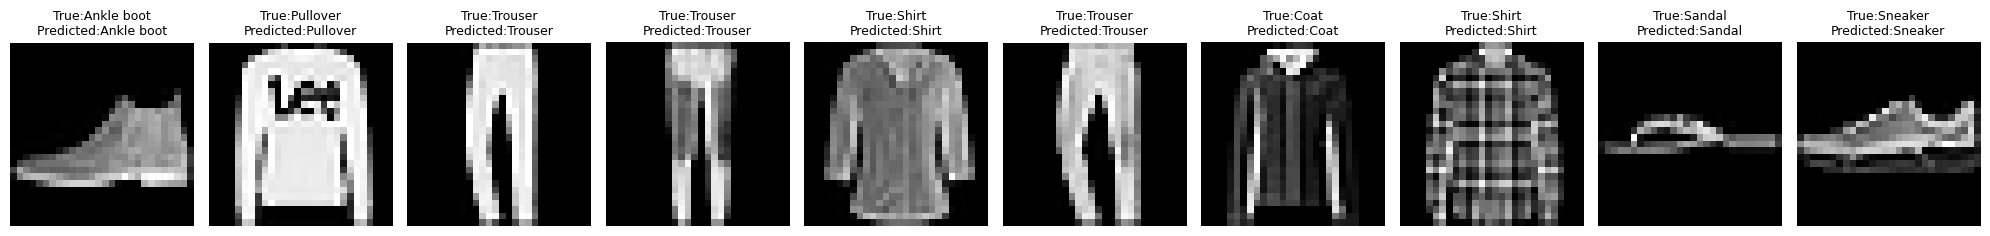

In [ ]:
y_pred = svm.predict(x_test_hog)

def plot_output_img(images, true_labels, predicted_labels, class_names):
    fig, axes = plt.subplots(1, 10, figsize=(20, 3))
    for i in range(10):
        ax = axes[i]
        ax.imshow(images[i], cmap='gray')
        ax.set_title(f"True:{class_names[true_labels[i]]}\nPredicted:{class_names[predicted_labels[i]]}", fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_output_img(x_test_small[:10], y_test_small[:10], y_pred[:10], class_names)